## representing image as graph

In [9]:
from PIL import Image
import os


# write code yourself only
def load_grayscale_image(img, mode="greyscale"):
    assert mode in ("greyscale", "color")
    if not os.path.isabs(img):
        img = os.path.join(os.path.dirname(__name__), img)
    with open(img, "rb") as f:
        image = Image.open(f).convert("RGB" if mode == "color" else "L")
        try:
            pixels = list(image.get_flattened_data())
        except AttributeError:
            pixels = list(image.getdata())
        width, height = image.size
        return {"mode": mode, "height": height, "width": width, "pixels": list(pixels)}

In [14]:
cat = load_grayscale_image("test_images/cat.png")

In [15]:
cat

{'mode': 'greyscale',
 'height': 184,
 'width': 300,
 'pixels': [129,
  129,
  119,
  118,
  129,
  135,
  138,
  140,
  144,
  144,
  137,
  138,
  150,
  145,
  148,
  147,
  153,
  154,
  146,
  139,
  147,
  155,
  151,
  150,
  142,
  142,
  144,
  143,
  144,
  155,
  154,
  153,
  151,
  147,
  163,
  154,
  153,
  163,
  168,
  175,
  167,
  167,
  155,
  165,
  160,
  162,
  163,
  155,
  164,
  153,
  146,
  155,
  154,
  151,
  152,
  151,
  161,
  159,
  157,
  166,
  162,
  176,
  181,
  181,
  180,
  181,
  180,
  183,
  176,
  175,
  177,
  170,
  174,
  178,
  176,
  177,
  186,
  177,
  176,
  174,
  177,
  178,
  180,
  185,
  185,
  170,
  181,
  180,
  183,
  180,
  181,
  186,
  188,
  177,
  184,
  189,
  185,
  193,
  188,
  187,
  197,
  186,
  187,
  189,
  190,
  192,
  191,
  187,
  186,
  184,
  184,
  191,
  186,
  183,
  195,
  202,
  186,
  185,
  190,
  203,
  194,
  194,
  189,
  178,
  188,
  185,
  178,
  187,
  195,
  189,
  190,
  185,
  184,
  179,

In [18]:
WIDTH, HEIGHT, PIXELS, MODE = "width", "height", "pixels", "mode"


def get_width(image):
    return image[WIDTH]


def get_height(image):
    return image[HEIGHT]


def get_index(image, row, col):
    return row * image[WIDTH] + col


def get_pixel(image, row, col):
    return image[PIXELS][get_index(image, row, col)]


def set_pixel(image, row, col, color):
    image[PIXELS][get_index(image, row, col)] = color


def blank_image(image):
    return {
        MODE: image[MODE],
        HEIGHT: image[HEIGHT],
        WIDTH: image[WIDTH],
        PIXELS: [0] * image[HEIGHT] * image[WIDTH],
    }


def apply_per_pixel(image, func):
    result = blank_image(image)
    for col in range(get_width(image)):
        for row in range(get_height(image)):
            color = get_pixel(image, row, col)
            new_color = func(color)
            set_pixel(result, row, col, new_color)
    return result


def inverted(image):
    if image is None:
        return None

    return apply_per_pixel(image, lambda color: 255 - color)

In [19]:
def save_image(image, filename, buffer_filetype="PNG"):
    """
    Saves the given image to disk or to a file-like object.  If filename is
    given as a string, the file type will be inferred from the given name.  If
    filename is given as a file-like object, the file type will be determined
    by the "buffer_filetype" parameter.
    """
    # make sure we have a valid image
    if image["mode"] not in {"greyscale", "color"}:
        raise ValueError(f"Unknown image mode: {image['mode']}")
    if (pixcount := image["height"] * image["width"]) != len(image["pixels"]):
        raise ValueError(
            f"Incorrect number of pixels (expected {pixcount}, got {len(image['pixels'])})"
        )
    if image["mode"] == "greyscale":
        if not all(isinstance(x, int) and 0 <= x <= 255 for x in image["pixels"]):
            msg = "Pixel values in a greyscale image must be integers between 0 and 255"
            raise ValueError(msg)
    else:
        msg = "Pixel values in a color image must be tuples of length 3"
        if not all(
            isinstance(tuple, p)
            and len(p) == 3
            and all(isinstance(x, int) and 0 <= x < 255 for x in p)
            for p in image["pixels"]
        ):
            msg = "Pixel values in a color image must be length-3 tuples of integers between 0 and 255"
            raise ValueError(msg)

    if isinstance(filename, str):
        if not os.path.isabs(filename):
            # treat relative paths as being relative to this file
            filename = os.path.join(os.path.dirname(__name__), filename)

            # make folders if they do not exist
            directory = os.path.realpath(os.path.dirname(filename))
            if directory and not os.path.exists(directory):
                os.makedirs(directory)

    # actually save image
    out = Image.new(
        mode=("L" if image["mode"] == "greyscale" else "RGB"),
        size=(image["width"], image["height"]),
    )
    out.putdata(image["pixels"])
    if isinstance(filename, str):
        out.save(filename)
    else:
        out.save(filename, buffer_filetype)
    out.close()

In [21]:
save_image(inverted(cat), "cat_inverted.png")

In [22]:
inverted(cat)

{'mode': 'greyscale',
 'height': 184,
 'width': 300,
 'pixels': [126,
  126,
  136,
  137,
  126,
  120,
  117,
  115,
  111,
  111,
  118,
  117,
  105,
  110,
  107,
  108,
  102,
  101,
  109,
  116,
  108,
  100,
  104,
  105,
  113,
  113,
  111,
  112,
  111,
  100,
  101,
  102,
  104,
  108,
  92,
  101,
  102,
  92,
  87,
  80,
  88,
  88,
  100,
  90,
  95,
  93,
  92,
  100,
  91,
  102,
  109,
  100,
  101,
  104,
  103,
  104,
  94,
  96,
  98,
  89,
  93,
  79,
  74,
  74,
  75,
  74,
  75,
  72,
  79,
  80,
  78,
  85,
  81,
  77,
  79,
  78,
  69,
  78,
  79,
  81,
  78,
  77,
  75,
  70,
  70,
  85,
  74,
  75,
  72,
  75,
  74,
  69,
  67,
  78,
  71,
  66,
  70,
  62,
  67,
  68,
  58,
  69,
  68,
  66,
  65,
  63,
  64,
  68,
  69,
  71,
  71,
  64,
  69,
  72,
  60,
  53,
  69,
  70,
  65,
  52,
  61,
  61,
  66,
  77,
  67,
  70,
  77,
  68,
  60,
  66,
  65,
  70,
  71,
  76,
  78,
  77,
  75,
  77,
  71,
  66,
  58,
  67,
  65,
  63,
  66,
  58,
  64,
  73,
  66

In [23]:
img["pixels"]

[129,
 129,
 119,
 118,
 129,
 135,
 138,
 140,
 144,
 144,
 137,
 138,
 150,
 145,
 148,
 147,
 153,
 154,
 146,
 139,
 147,
 155,
 151,
 150,
 142,
 142,
 144,
 143,
 144,
 155,
 154,
 153,
 151,
 147,
 163,
 154,
 153,
 163,
 168,
 175,
 167,
 167,
 155,
 165,
 160,
 162,
 163,
 155,
 164,
 153,
 146,
 155,
 154,
 151,
 152,
 151,
 161,
 159,
 157,
 166,
 162,
 176,
 181,
 181,
 180,
 181,
 180,
 183,
 176,
 175,
 177,
 170,
 174,
 178,
 176,
 177,
 186,
 177,
 176,
 174,
 177,
 178,
 180,
 185,
 185,
 170,
 181,
 180,
 183,
 180,
 181,
 186,
 188,
 177,
 184,
 189,
 185,
 193,
 188,
 187,
 197,
 186,
 187,
 189,
 190,
 192,
 191,
 187,
 186,
 184,
 184,
 191,
 186,
 183,
 195,
 202,
 186,
 185,
 190,
 203,
 194,
 194,
 189,
 178,
 188,
 185,
 178,
 187,
 195,
 189,
 190,
 185,
 184,
 179,
 177,
 178,
 180,
 178,
 184,
 189,
 197,
 188,
 190,
 192,
 189,
 197,
 191,
 182,
 189,
 186,
 183,
 191,
 188,
 190,
 183,
 185,
 188,
 187,
 186,
 174,
 173,
 185,
 186,
 184,
 185,
 178,
 175

In [24]:
img = Image.open("cat_inverted.png")

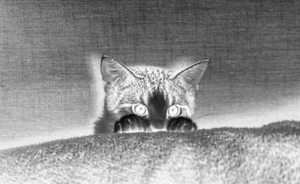

In [25]:
img